In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False

In [84]:
df = pd.read_csv('2003-2025 Championships.csv')
print(df.columns.tolist())
print(df.shape)
df_filtered = df[(df['Year'] >= 2022) & (df['Year'] <= 2025) & (df['Round'] == 'Final')].copy()
df_filtered['Name'] = df_filtered['Name'].str.replace(r'[\n\r]', ' ', regex=True)
print("(2022-2025 Final)data shape:", df_filtered.shape)

['Name', 'Age', 'Country', 'Points', 'Dive', 'Dive No.', 'DD', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'Dive Pts', 'Total Pts', 'Year', 'Round']
(3010, 18)
(2022-2025 Final)data shape: (240, 18)


In [85]:
numeric_cols = ['Year', 'DD', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7']
for col in numeric_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')
df_filtered = df_filtered.dropna(subset=numeric_cols)
print("after outliner handling data shape", df_filtered.shape)
def calculate_valid_score(row):
    """
    Calculate the valid referee scores: Remove the 2 highest and 2 lowest scores from the 7 referee scores, and take the sum of the remaining 3
    """
    judge_scores = [row[f'J{i}'] for i in range(1, 8)]
    judge_scores_sorted = sorted(judge_scores)
    valid_scores = judge_scores_sorted[2:-2]  
    return sum(valid_scores)
df_filtered['Valid_Judge_Sum'] = df_filtered.apply(calculate_valid_score, axis=1)

after outliner handling data shape (240, 18)


In [86]:
#The highest theoretical score
df_filtered['Theoretical_Max'] = df_filtered['DD'] * 10 * 3

#The actual score of a single jump
df_filtered['Actual_Score'] = (df_filtered['Valid_Judge_Sum'] * df_filtered['DD']).round(2)

#Deduction value
df_filtered['Deduction'] = df_filtered['Theoretical_Max'] - df_filtered['Actual_Score']
df_filtered['Deduction'] = df_filtered['Deduction'].apply(lambda x: max(x, 0))

#Deduction rate (deduction value/theoretical maximum score ×100%)
df_filtered['Deduction_Rate'] = (df_filtered['Deduction'] / df_filtered['Theoretical_Max'] * 100).round(2)

print(df_filtered[["Country","Name", 'DD', 'Valid_Judge_Sum', 'Actual_Score','Theoretical_Max', 'Deduction', 'Deduction_Rate']].head())

     Country       Name   DD  Valid_Judge_Sum  Actual_Score  Theoretical_Max  \
2065     CHN  Yuxi CHEN  3.0             27.0         81.00             90.0   
2066     CHN  Yuxi CHEN  3.2             28.5         91.20             96.0   
2067     CHN  Yuxi CHEN  3.3             26.0         85.80             99.0   
2068     CHN  Yuxi CHEN  3.3             24.5         80.85             99.0   
2069     CHN  Yuxi CHEN  3.2             24.5         78.40             96.0   

      Deduction  Deduction_Rate  
2065       9.00           10.00  
2066       4.80            5.00  
2067      13.20           13.33  
2068      18.15           18.33  
2069      17.60           18.33  


In [87]:
athlete_action_count = df_filtered['Name'].value_counts()
valid_athletes = athlete_action_count[athlete_action_count >=5].index.tolist()
df_athlete = df_filtered[df_filtered['Name'].isin(valid_athletes)].copy()
print(df_athlete[['Name',"Country"]].value_counts().head)

<bound method NDFrame.head of Name                        Country
Yuxi CHEN                   CHN        20
Hongchan QUAN               CHN        15
Caeli MCKAY                 CAN        15
Sarah JODOIN DI MARIA       ITA        15
Else PRAASTERINK            NED        10
Christina WASSEN            GER        10
Alejandra OROZCO LOZA       MEX        10
Lois TOULSON                GBR        10
Ingrid OLIVEIRA             BRA        10
Pauline Alexandra PFEIF     GER        10
Matsuri ARAI                JPN        10
Gabriela AGUNDEZ GARCIA     MEX        10
Ana CARVAJAL                ESP         5
Bayleigh CRANFORD           USA         5
Alejandra ESTUDILLO TORRES  MEX         5
Emily BOYD                  AUS         5
Ellie COLE                  AUS         5
Ella ROSELLI                USA         5
Elena WASSEN                GER         5
Delaney SCHNELL             USA         5
Ekaterina BELIAEVA          NAB         5
Daryn WRIGHT                USA         5
Andrea SPE

In [88]:
athlete_stats = df_athlete.groupby('Name').agg({
    'DD': ['mean', 'count'],  
    'Deduction_Rate': ['mean', 'std'],  
    'Country': 'first'  
}).round(2)

athlete_stats.columns = ['Avg_Difficulty', 'Action_Count', 'Avg_Deduction_Rate', 'Deduction_Rate_Std', 'Country']

athlete_stats = athlete_stats.reset_index()
print(athlete_stats[['Name', 'Country', 'Avg_Difficulty', 'Avg_Deduction_Rate', 'Deduction_Rate_Std', 'Action_Count']].head)

<bound method NDFrame.head of                           Name Country  Avg_Difficulty  Avg_Deduction_Rate  \
0   Alejandra ESTUDILLO TORRES     MEX            3.36               42.33   
1        Alejandra OROZCO LOZA     MEX            3.08               34.67   
2                 Ana CARVAJAL     ESP            2.78               25.00   
3    Andrea SPENDOLINI SIRIEIX     GBR            3.08               18.33   
4            Bayleigh CRANFORD     USA            3.22               32.00   
5                  Caeli MCKAY     CAN            3.10               30.22   
6             Christina WASSEN     GER            3.10               39.83   
7                 Daryn WRIGHT     USA            3.18               41.67   
8              Delaney SCHNELL     USA            3.18               34.33   
9           Ekaterina BELIAEVA     NAB            3.08               27.33   
10                Elena WASSEN     GER            3.10               37.00   
11                Ella ROSELLI    

In [89]:

def classify_athlete(row):
    avg_diff = row['Avg_Difficulty']
    avg_ded = row['Avg_Deduction_Rate']
    ded_std = row['Deduction_Rate_Std']
    
   
    if avg_diff >=3.18  and avg_ded <=15:
        return 'Outstanding in strength type', 'High difficulty and high quality'
    elif 3.17>= avg_diff >= 3.10 and avg_ded <= 25:
        return 'Balanced competition type', 'Medium to high difficulty and high quality'
    elif avg_diff <= 3.10 and avg_ded <= 25:
        return 'Stable efficiency type', 'Medium to low difficulty but high quality'
    elif avg_diff >= 3.18 and avg_ded >= 25:
        return 'High-difficulty challenge type', 'High difficulty but low quality'
    elif avg_diff <= 3.10 and 35>=avg_ded >=25:
        return 'Ordinary type', 'Medium to low difficulty, medium to low quality'
    else:
        return 'Nothing works', 'Medium to low difficulty and low quality'

athlete_stats[['Strategy_Type', 'Strategy_Description']] = athlete_stats.apply(
    classify_athlete, axis=1, result_type='expand'
)

strategy_dist = athlete_stats['Strategy_Type'].value_counts()
print(strategy_dist)

print(f"\nclassify result")
for strategy in athlete_stats['Strategy_Type'].unique():
    sample = athlete_stats[athlete_stats['Strategy_Type'] == strategy].head()
    print(f"\n{strategy}:")
    print(sample[['Name', 'Country', 'Avg_Difficulty', 'Avg_Deduction_Rate', 'Strategy_Description']])

Strategy_Type
Ordinary type                     12
Nothing works                      8
High-difficulty challenge type     6
Stable efficiency type             2
Outstanding in strength type       2
Balanced competition type          1
Name: count, dtype: int64

classify result

High-difficulty challenge type:
                          Name Country  Avg_Difficulty  Avg_Deduction_Rate  \
0   Alejandra ESTUDILLO TORRES     MEX            3.36               42.33   
4            Bayleigh CRANFORD     USA            3.22               32.00   
7                 Daryn WRIGHT     USA            3.18               41.67   
8              Delaney SCHNELL     USA            3.18               34.33   
15     Gabriela AGUNDEZ GARCIA     MEX            3.20               33.00   

               Strategy_Description  
0   High difficulty but low quality  
4   High difficulty but low quality  
7   High difficulty but low quality  
8   High difficulty but low quality  
15  High difficulty but low q

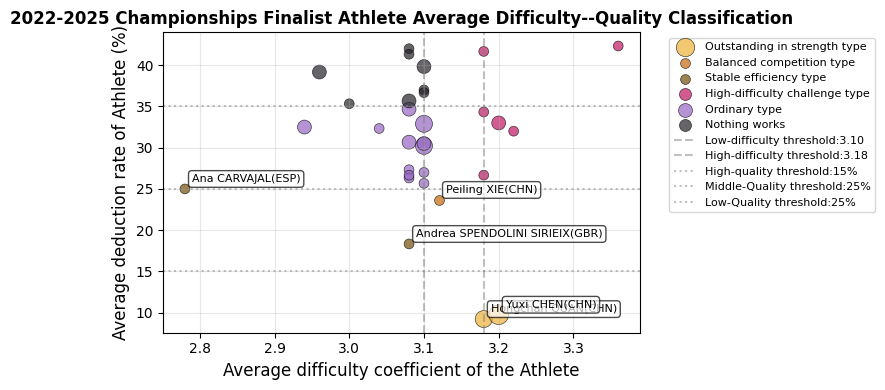


picture has been saved to: athlete_strategy_classification.png


In [90]:

plt.figure(figsize=(8, 4))

strategy_colors = {
    'Outstanding in strength type': "#eeb138",  
    'Balanced competition type': "#C6680B",          
    'Stable efficiency type': "#744E08",          
    'High-difficulty challenge type': "#bf1564",          
    'Ordinary type': "#9666c2",
    'Nothing works': "#262329"
}

for strategy, color in strategy_colors.items():
    strategy_data = athlete_stats[athlete_stats['Strategy_Type'] == strategy]
    plt.scatter(
        strategy_data['Avg_Difficulty'],
        strategy_data['Avg_Deduction_Rate'],
        s=strategy_data['Action_Count'] * 10,
        color=color,
        alpha=0.7,
        label=strategy,
        edgecolors='black',  
        linewidth=0.5
    )

plt.axvline(x=3.10, color='gray', linestyle='--', alpha=0.5, label=f'Low-difficulty threshold:3.10')
plt.axvline(x=3.18, color='gray', linestyle='--', alpha=0.5, label=f'High-difficulty threshold:3.18')
plt.axhline(y=15, color='gray', linestyle=':', alpha=0.5, label=f'High-quality threshold:15%')
plt.axhline(y=25, color='gray', linestyle=':', alpha=0.5, label=f'Middle-Quality threshold:25%')
plt.axhline(y=35, color='gray', linestyle=':', alpha=0.5, label=f'Low-Quality threshold:25%')


major_athletes = athlete_stats[athlete_stats['Strategy_Type'].isin(["Outstanding in strength type","Balanced competition type","Stable efficiency type"])]
for idx, row in major_athletes.iterrows():
    plt.annotate(
        f"{row['Name']}({row['Country']})",  
        xy=(row['Avg_Difficulty'], row['Avg_Deduction_Rate']),
        xytext=(5, 5),  
        textcoords='offset points',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)  
    )


plt.xlabel('Average difficulty coefficient of the Athlete', fontsize=12)
plt.ylabel('Average deduction rate of Athlete (%)', fontsize=12)
plt.title('2022-2025 Championships Finalist Athlete Average Difficulty--Quality Classification', fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=8)  
plt.grid(alpha=0.3)


plt.tight_layout()
plt.savefig('athlete_strategy_classification.png', dpi=300, bbox_inches='tight')
plt.show()

print("\npicture has been saved to: athlete_strategy_classification.png")